# Stock Forecasting with Historical Prices and Market News

## Executive report

> **Research question:** Does market news improve next-trading-day stock-price
> forecasting beyond historical price and volume information?

This project combines daily OHLCV prices for seven technology companies with
4,439 cleaned market-news articles. FinBERT transforms the text into financial
sentiment features, and multiple machine-learning and time-series models are
compared with carefully constructed historical-drift baselines.

### Principal result

News sentiment slightly improves validation performance, but the improvement
does not persist on the final unseen test period. The ticker-specific
historical-mean forecast is the strongest final benchmark.

Within this one-year sample, additional model complexity does not consistently
overcome the noise and regime instability of next-day stock returns.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

CURRENT_DIRECTORY = Path.cwd()

PROJECT_ROOT = (
    CURRENT_DIRECTORY.parent
    if CURRENT_DIRECTORY.name == "notebooks"
    else CURRENT_DIRECTORY
)

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/camilo/stock-news-forecasting


Load Saved Artifacts

In [3]:
prices = pd.read_csv(
    RAW_DATA_DIR / "price.csv",
    parse_dates=["date"],
)

news_sentiment = pd.read_csv(
    PROCESSED_DATA_DIR
    / "news_with_finbert_sentiment.csv",
    parse_dates=["datetime"],
)

model_results = pd.read_csv(
    METRICS_DIR / "model_comparison.csv"
)

print(f"Price observations: {len(prices):,}")
print(f"Scored news articles: {len(news_sentiment):,}")
print(f"Saved model evaluations: {len(model_results):,}")

Price observations: 1,687
Scored news articles: 4,439
Saved model evaluations: 20


## Data and quality summary

The price panel contains 241 trading sessions for each of seven stocks:

- AAPL
- AMZN
- GOOGL
- META
- MSFT
- NVDA
- TSLA

The price data contains no missing values, duplicate ticker-date observations,
nonpositive prices, negative volume, or OHLC consistency violations.

The raw news data contained one exact duplicate, which was removed. Repeated
timestamps and headlines were retained when they represented distinct or
recurring coverage. The cleaned news corpus contains 4,439 articles.

Data Summary

In [4]:
data_summary = pd.DataFrame(
    {
        "Measure": [
            "Price rows",
            "Trading sessions",
            "Tickers",
            "Clean news articles",
            "First price date",
            "Last price date",
            "Missing price values",
            "Duplicate ticker-date rows",
        ],
        "Value": [
            f"{len(prices):,}",
            prices["date"].nunique(),
            prices["ticker"].nunique(),
            f"{len(news_sentiment):,}",
            prices["date"].min().date(),
            prices["date"].max().date(),
            int(prices.isna().sum().sum()),
            int(
                prices.duplicated(
                    ["ticker", "date"]
                ).sum()
            ),
        ],
    }
)

display(data_summary)

,Measure,Value
0,Price rows,"1,687"
1,Trading sessions,241
2,Tickers,7
3,Clean news articles,"4,439"
4,First price date,2023-11-13
5,Last price date,2024-10-28
6,Missing price values,0
7,Duplicate ticker-date rows,0


In [9]:
def show_saved_figure(
    filename: str,
    description: str,
    width: int = 800,
) -> None:
    path = FIGURES_DIR / filename

    if path.exists():
        display(
            Image(
                filename=str(path),
                width=width,
            )
        )
    else:
        display(
            Markdown(
                f"*{description} is generated by "
                "the detailed EDA notebook.*"
            )
        )

## 2. Market behavior

Normalized prices make performance comparable despite different nominal share
prices. NVIDIA generated the strongest cumulative return. Tesla and NVIDIA had
the highest daily volatility, while Microsoft had the lowest.

All seven stocks had positive daily-return correlations. Tesla had comparatively
weak relationships with the rest of the group, suggesting a larger
company-specific component in its daily movement.

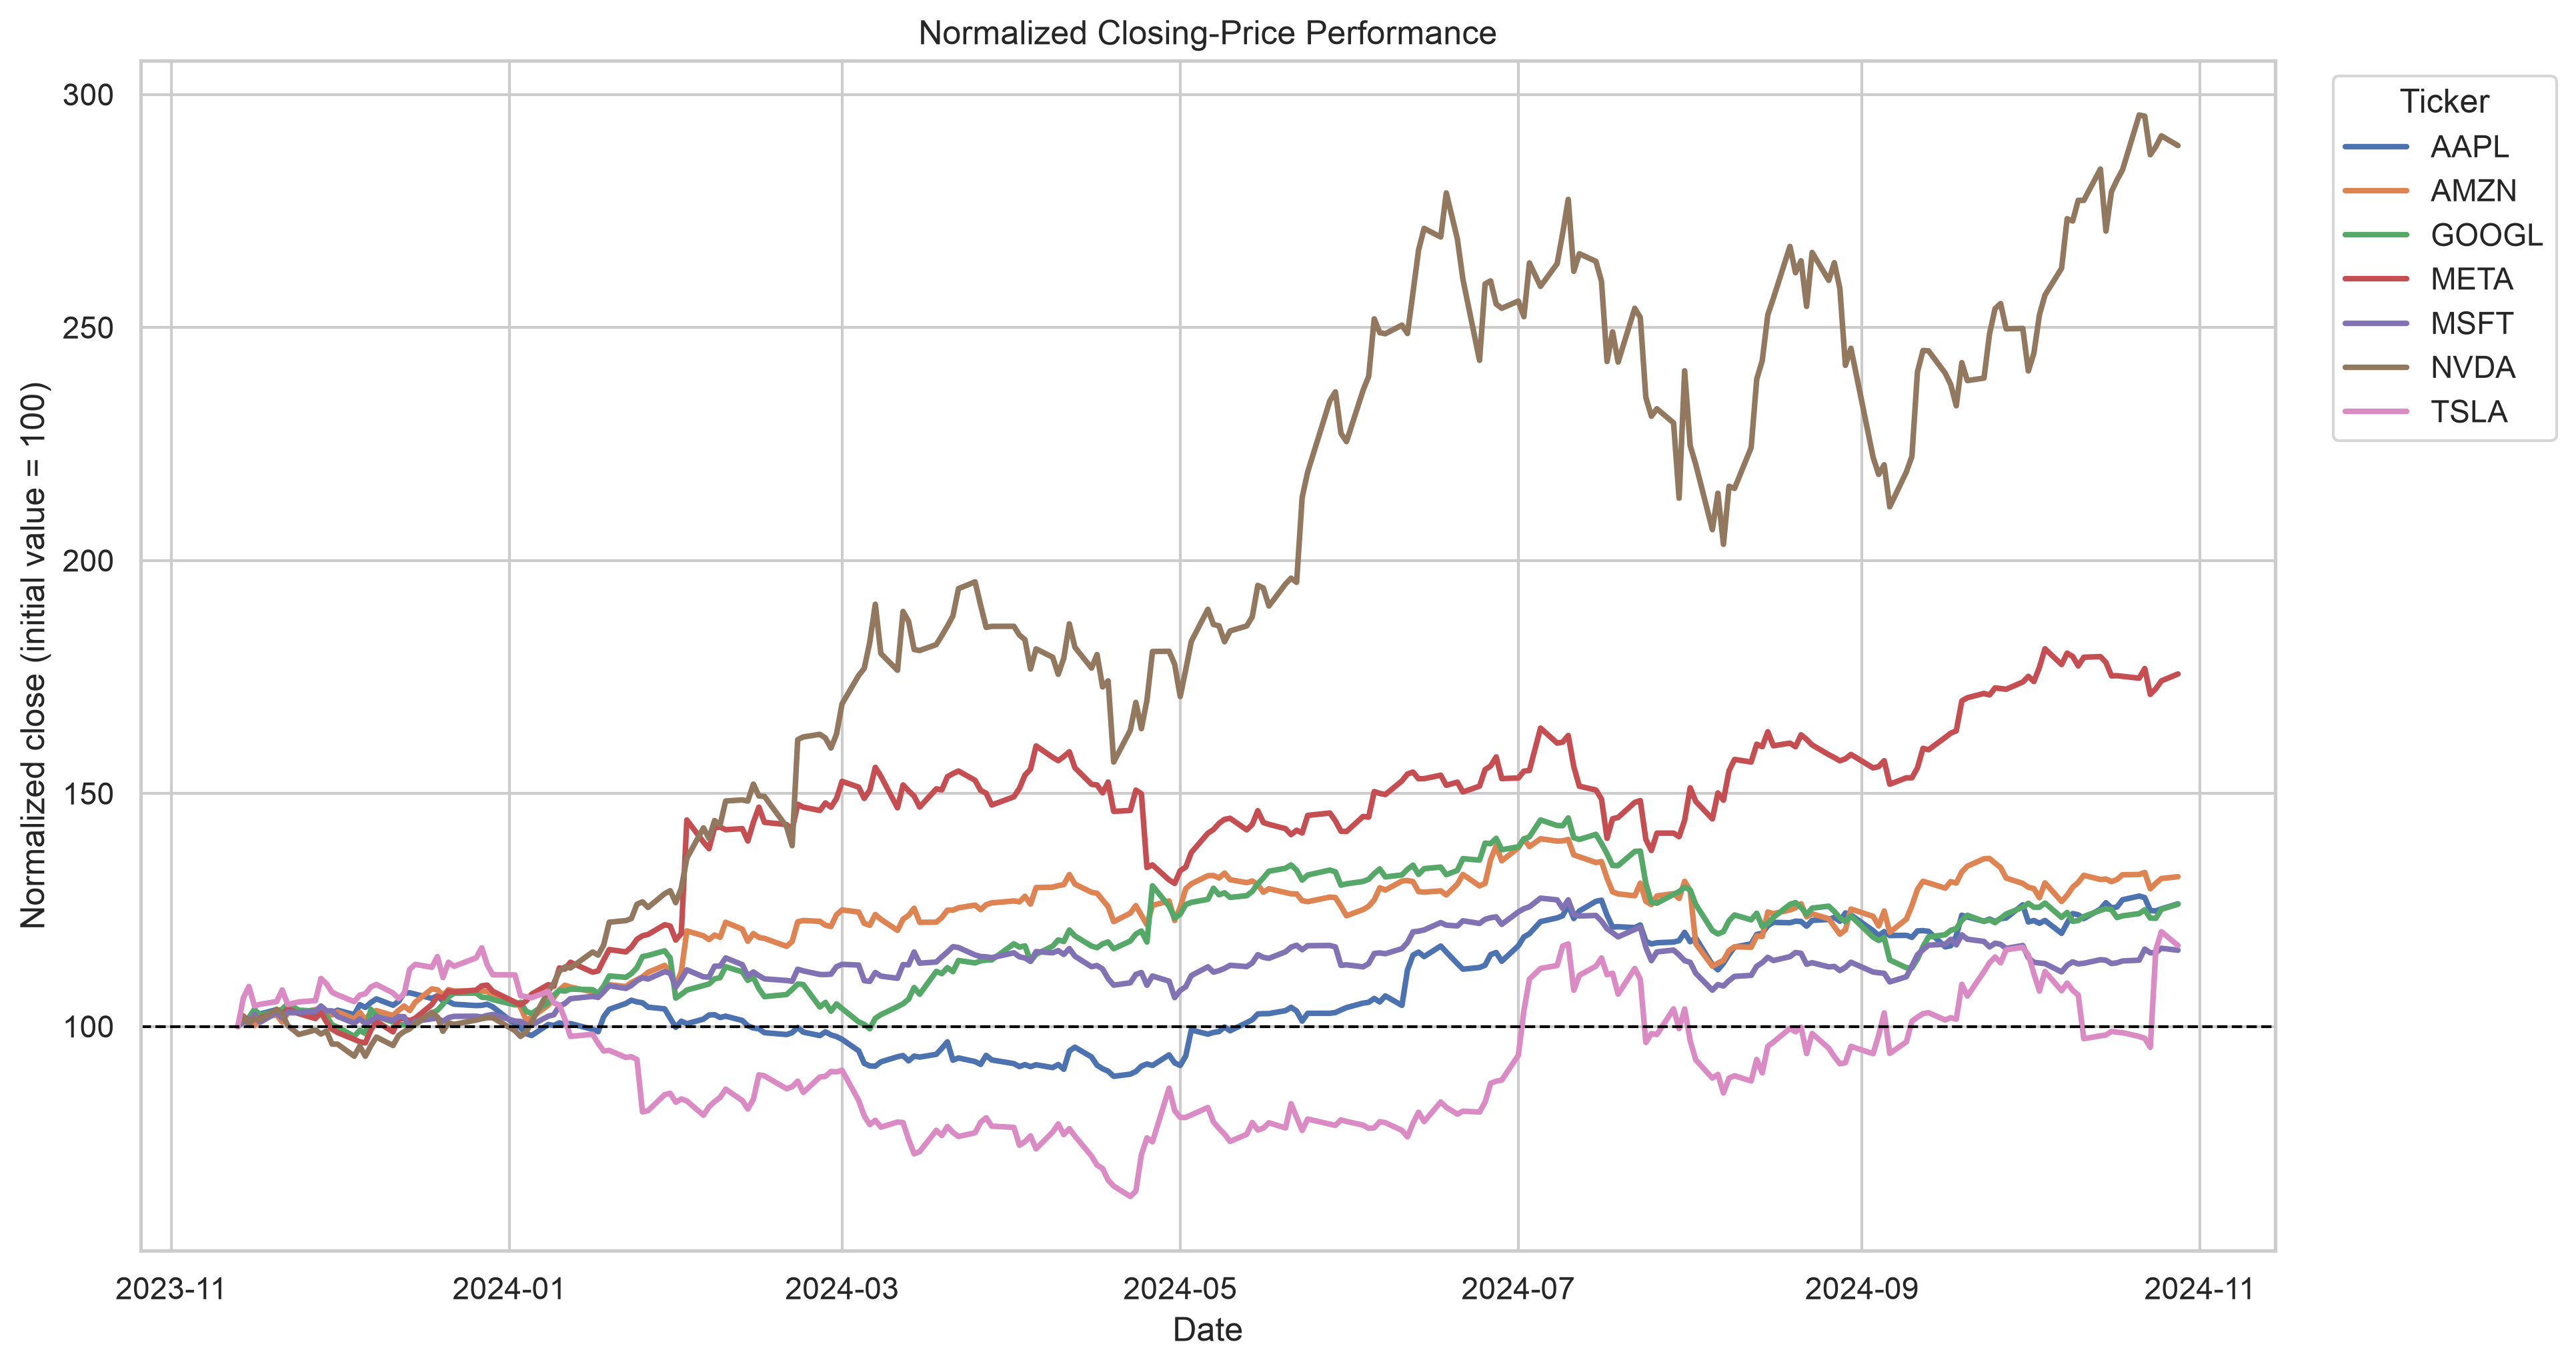

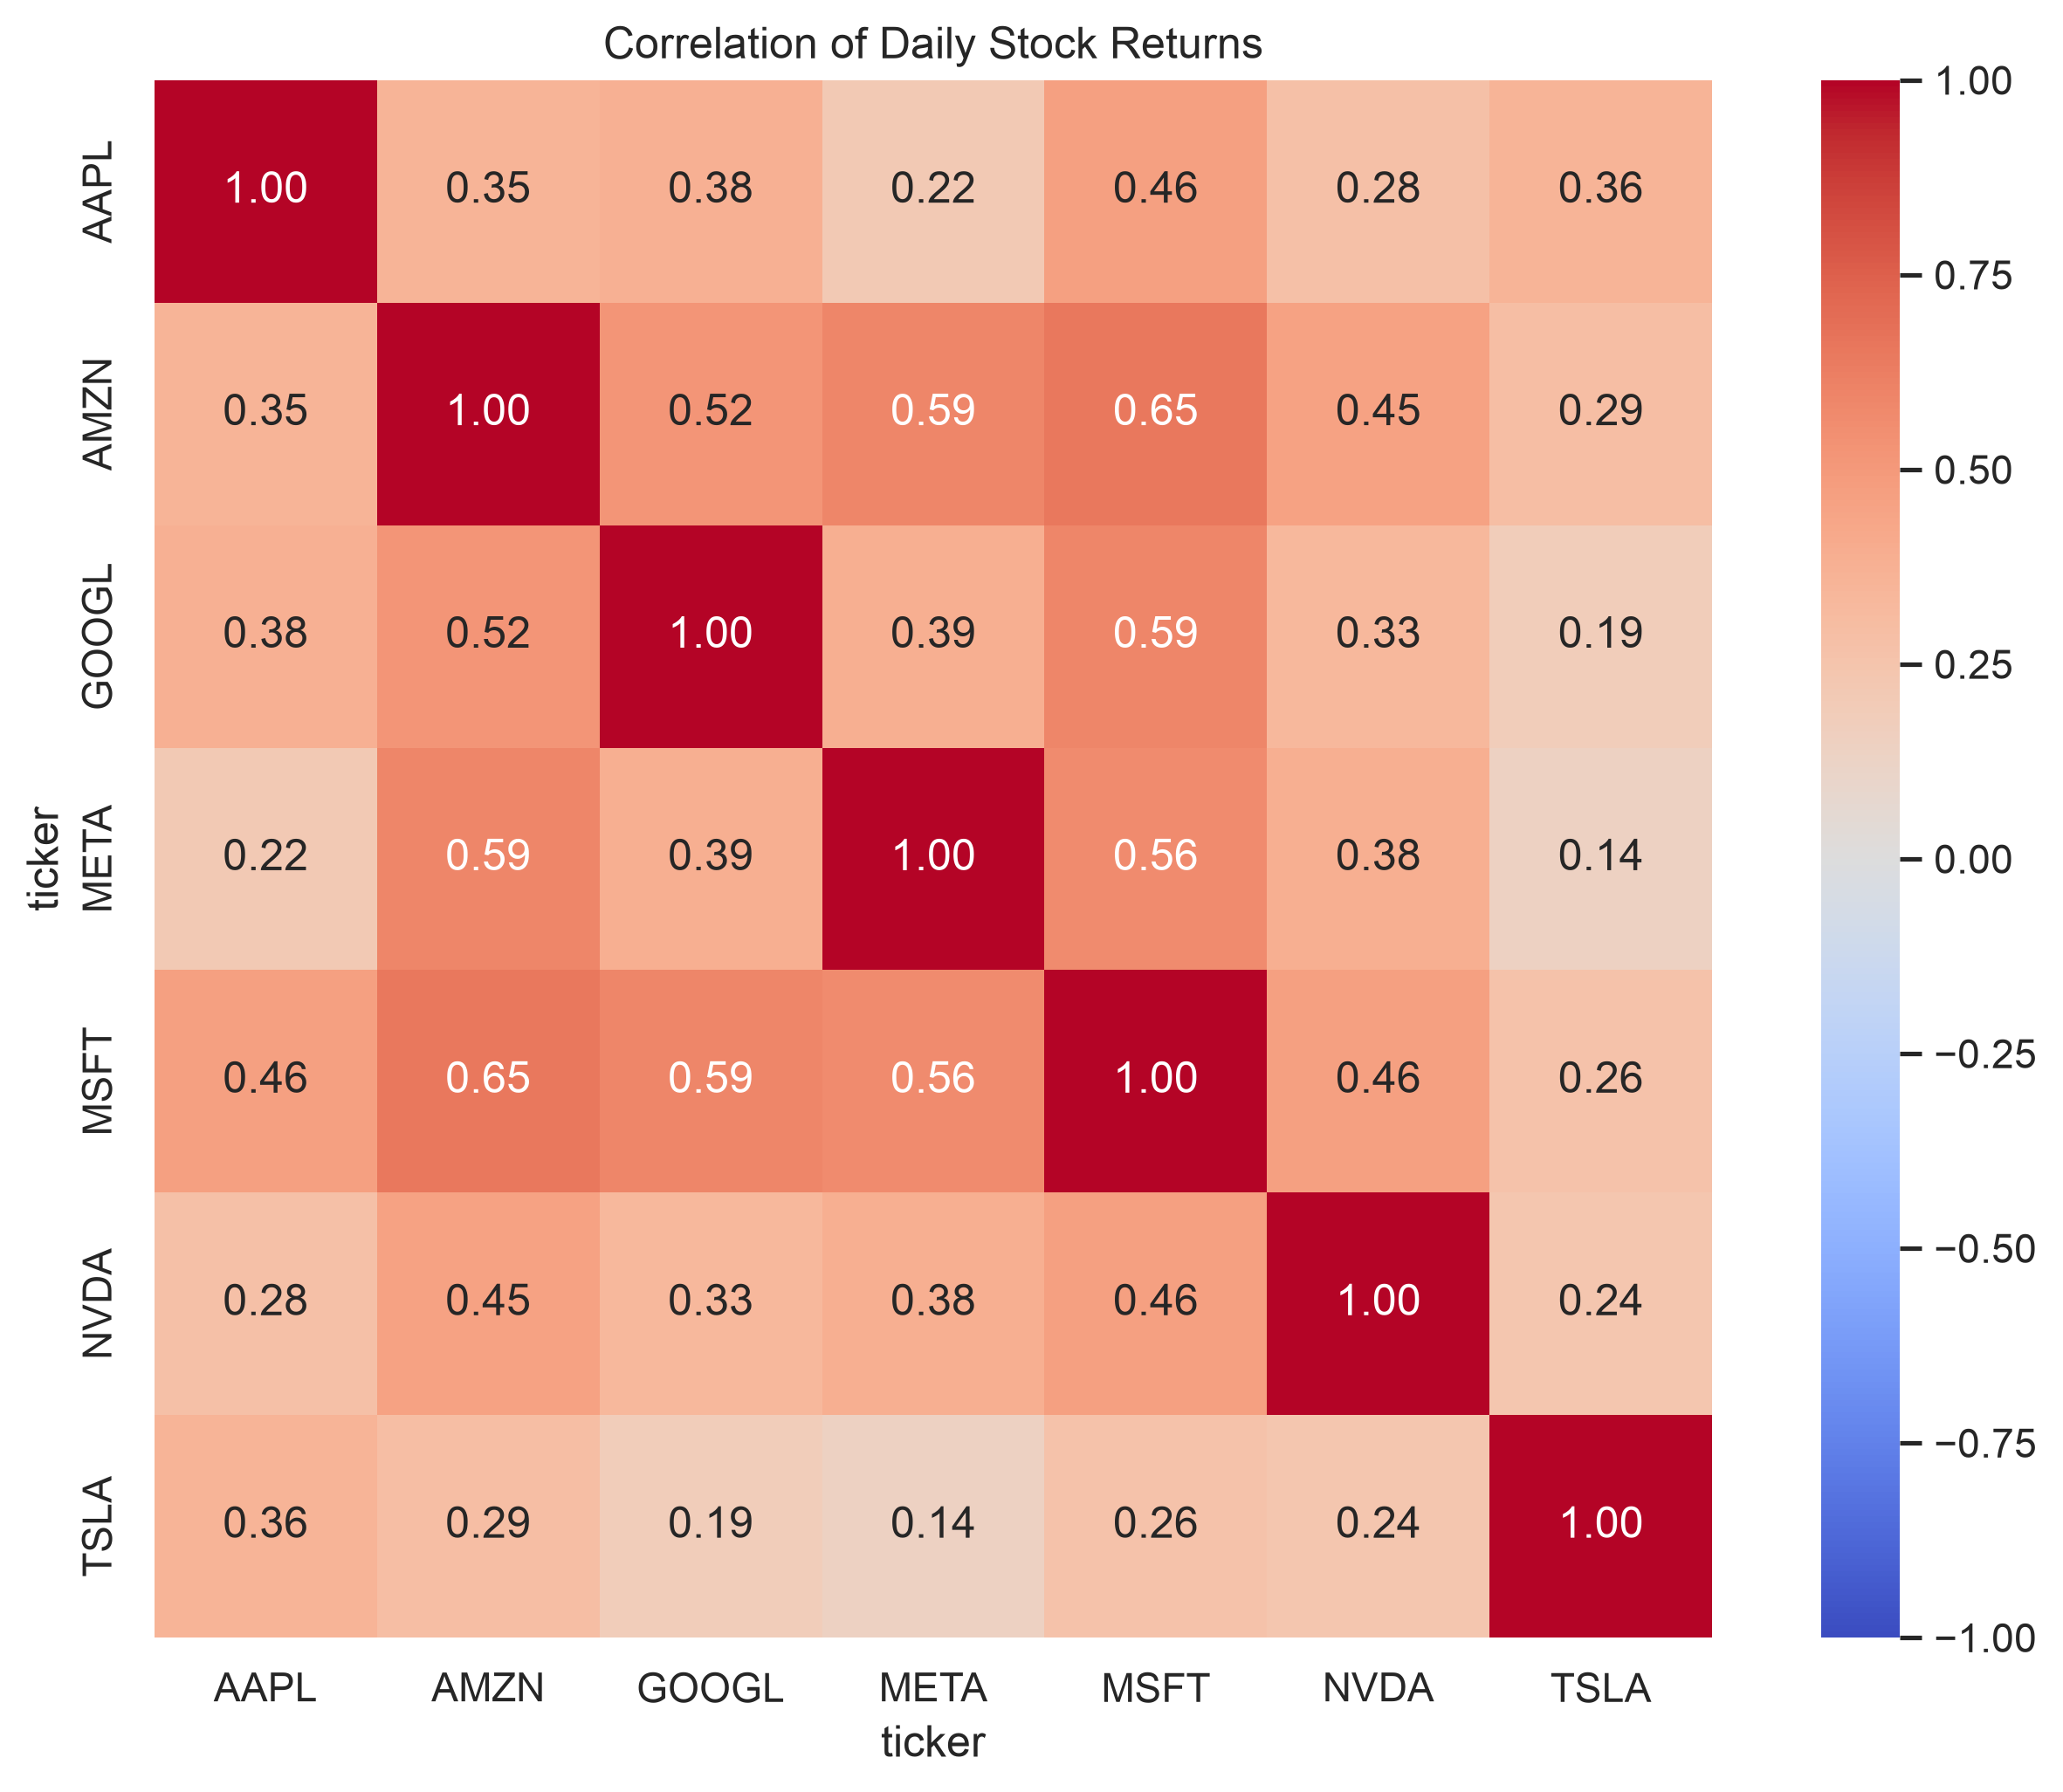

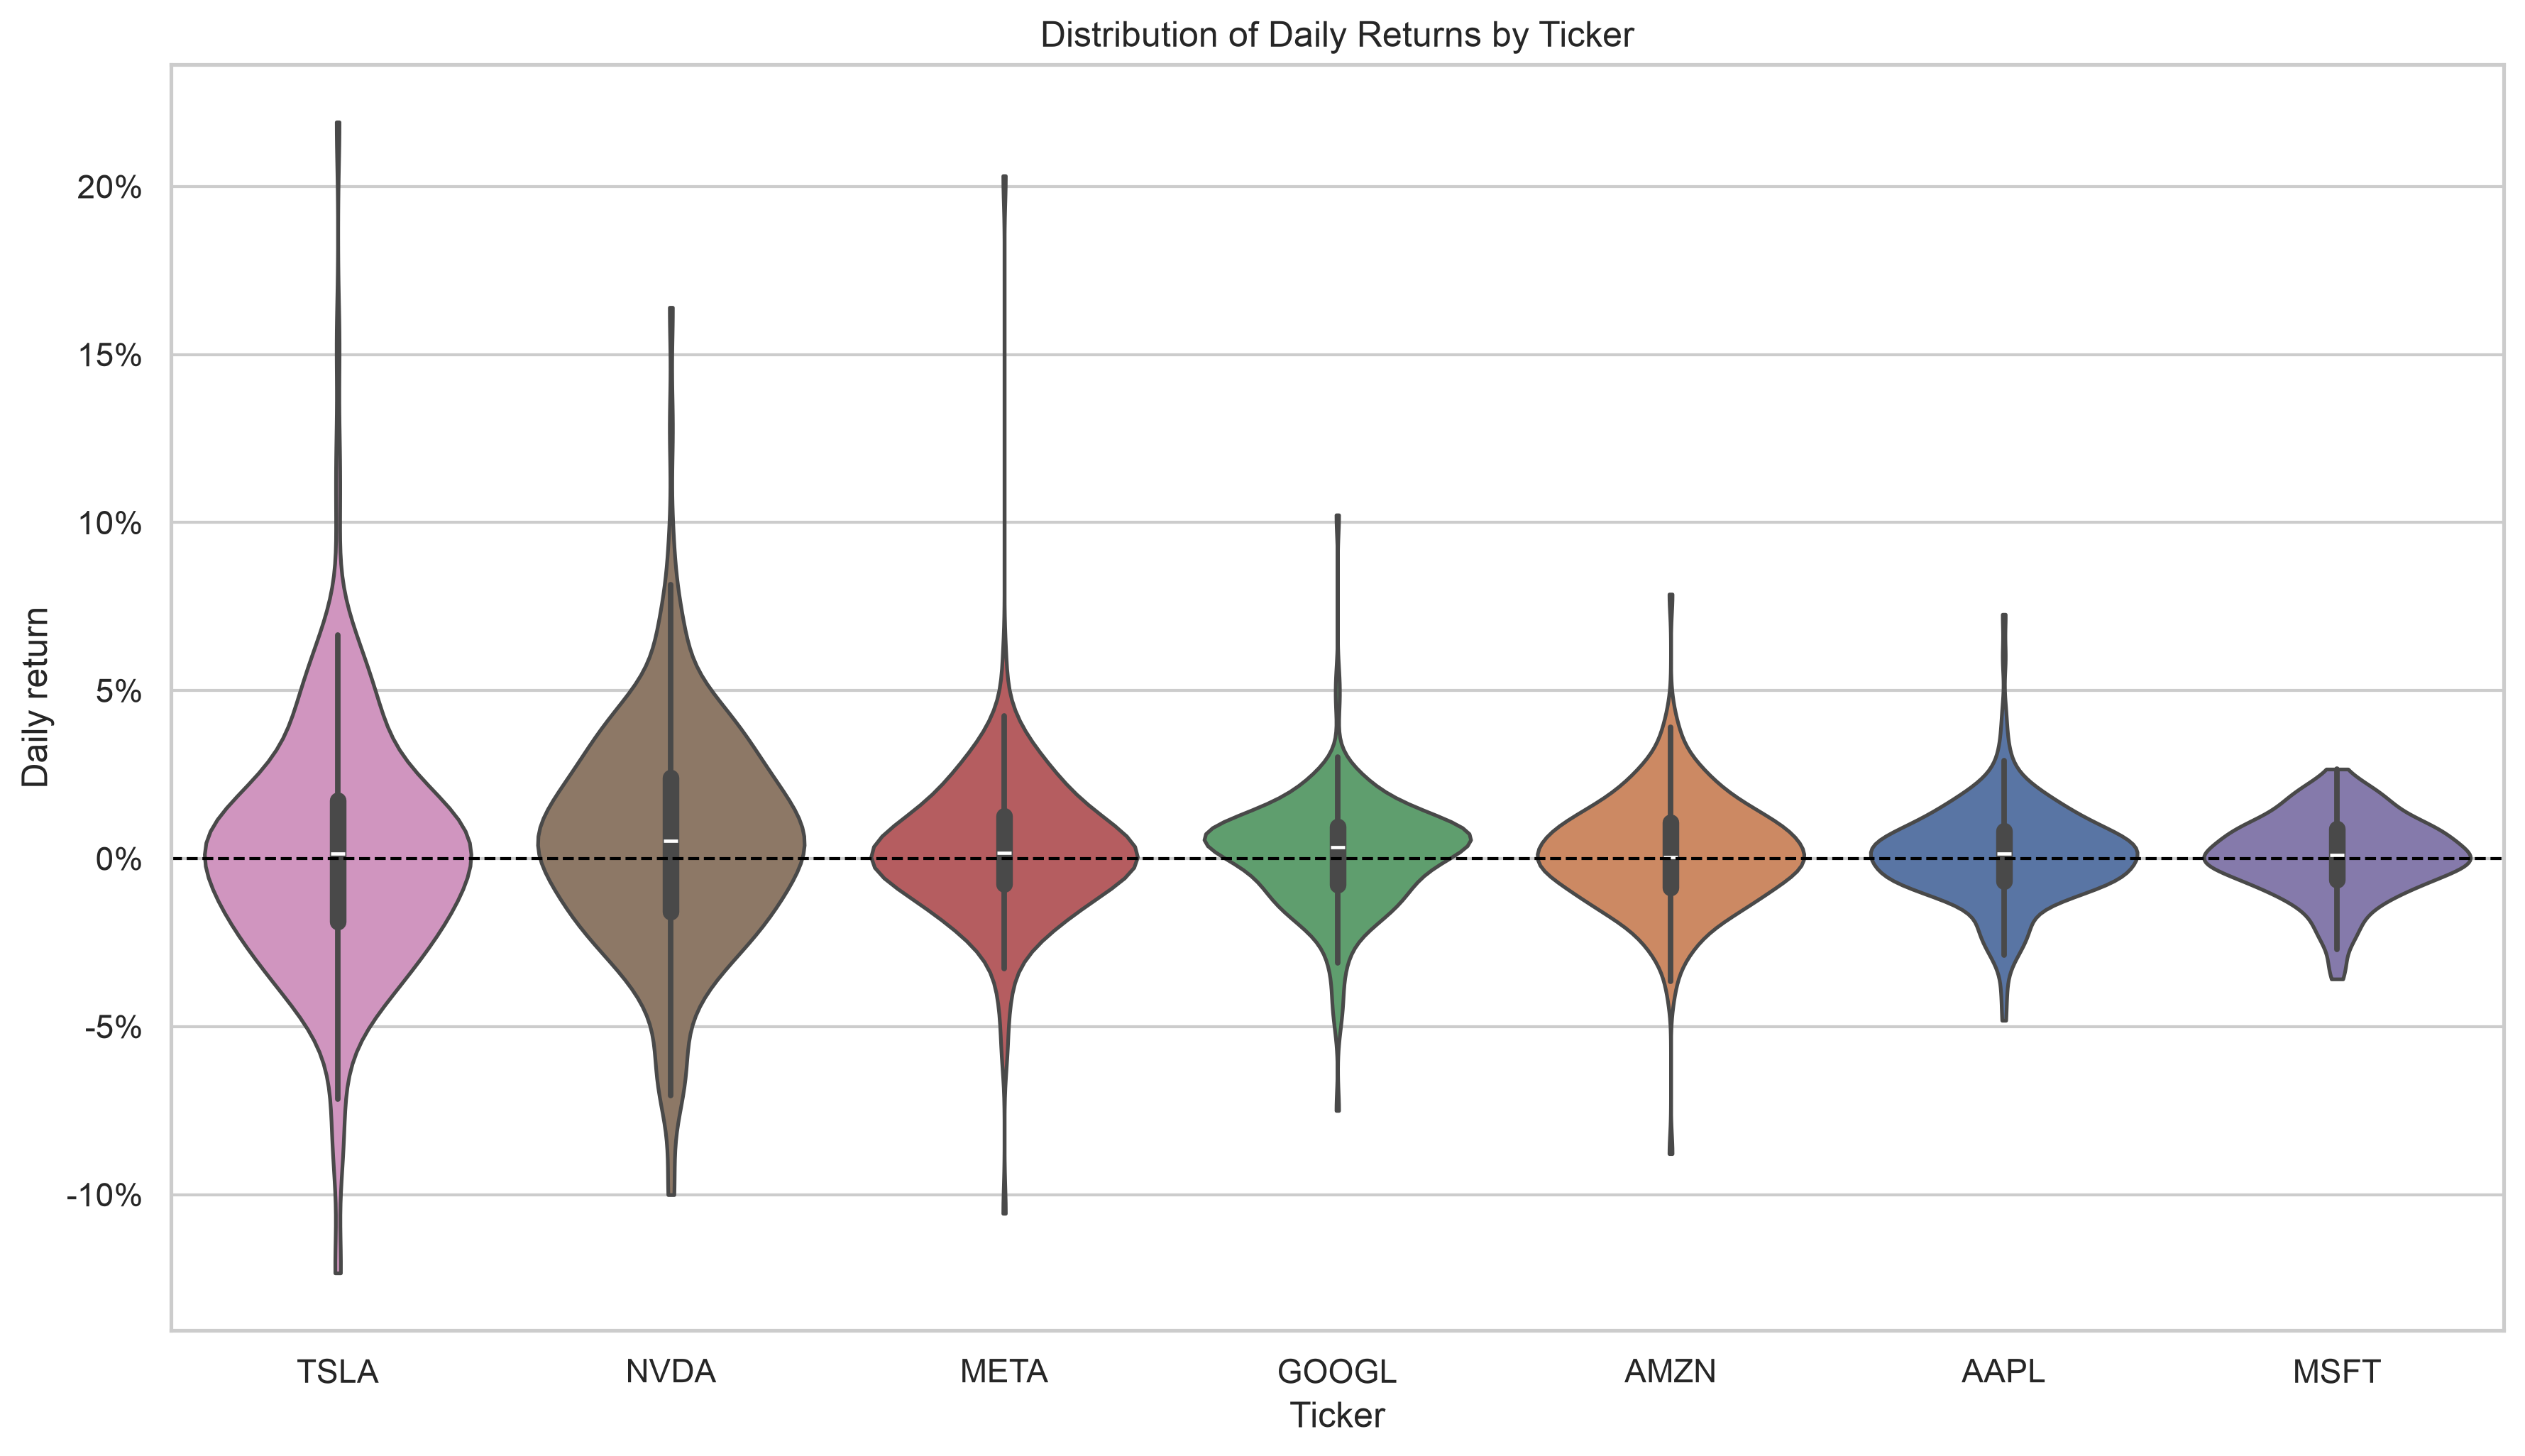

In [10]:
show_saved_figure(
    "normalized_price_performance.png",
    "Normalized-price performance chart",
    width=750,
)

show_saved_figure(
    "daily_return_correlation.png",
    "Daily-return correlation matrix",
    width=600,
)

show_saved_figure(
    "daily_return_violin_plot.png",
    "Daily-return violin plot",
    width=700,
)

## 3. Prediction design and leakage controls

At the end of trading day $t$, the model predicts the return for the next
trading session:

$$
r_{i,t+1}
=
\frac{\mathrm{Close}_{i,t+1}}
{\mathrm{Close}_{i,t}}
- 1
$$

The return prediction is converted into a closing-price forecast:

$$
\widehat{\mathrm{Close}}_{i,t+1}
=
\mathrm{Close}_{i,t}
\left(1+\widehat{r}_{i,t+1}\right)
$$

Leakage controls include:

- Chronological rather than random dataset splits.
- All stocks from the same market date remain in the same split.
- Rolling features use only current and earlier observations.
- News is assigned to the first trading session strictly after its calendar
  publication date because the timestamp timezone is undocumented.
- Model development uses validation performance; the final test period is used
  for final assessment.

## 4. Feature families

| Feature family | Examples |
|---|---|
| Momentum | 1-, 2-, 5-, 10-, and 20-day returns |
| Risk | Rolling volatility and intraday range |
| Trend | Closing price relative to moving averages |
| Volume | Daily change and relative 20-day volume |
| Market context | Equal-weight market return and relative return |
| News intensity | Article count, unique headlines, news availability |
| News tone | Mean, median, minimum, maximum, and dispersion |
| News composition | Positive, neutral, and negative article shares |

FinBERT is used as a pretrained feature extractor rather than as the forecasting
model. The forecasting models are trained on the assignment data.

## 5. Models evaluated

- Random walk
- Global historical-mean return
- Ticker-specific historical-mean return
- Ridge regression
- Price-only XGBoost
- News-only XGBoost
- Price-plus-news XGBoost
- Damped Holt exponential smoothing
- ARIMA(1,0,0) with walk-forward evaluation
- Validation-weighted ensemble

Every complex model is compared with historical drift. This prevents a small
positive average return from being mistaken for meaningful directional skill.

In [11]:
validation_results = (
    model_results[
        model_results["split"] == "validation"
    ]
    .sort_values("return_mae")
    .reset_index(drop=True)
)

display(
    validation_results[
        [
            "model",
            "price_mae",
            "price_rmse",
            "return_mae",
            "return_rmse",
            "direction_accuracy",
        ]
    ].style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        },
        na_rep="—",
    )
)

,model,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,XGBoost: news only,$4.277,$5.952,1.925%,2.776%,56.28%
1,Validation-weighted ensemble,$4.281,$5.957,1.931%,2.779%,54.98%
2,Global historical mean,$4.286,$5.970,1.937%,2.783%,54.98%
3,XGBoost: price + news,$4.290,$5.972,1.937%,2.782%,54.98%
4,XGBoost,$4.287,$5.968,1.937%,2.783%,54.98%
5,Ticker historical mean,$4.296,$5.964,1.938%,2.786%,54.98%
6,"ARIMA(1,0,0)",$4.299,$5.963,1.940%,2.780%,51.08%
7,Damped Holt,$4.301,$5.958,1.965%,2.798%,49.78%


### Validation finding

News-only XGBoost produces the strongest validation-period errors. This
suggests that sentiment and news composition contain limited predictive
information during the validation.

However, validation performance alone is insufficient. The selected model must
also demonstrate that its advantage persists on the final unseen period.

Test results

In [12]:
test_results = (
    model_results[
        model_results["split"] == "test"
    ]
    .sort_values("return_mae")
    .reset_index(drop=True)
)

display(
    test_results[
        [
            "model",
            "price_mae",
            "price_rmse",
            "return_mae",
            "return_rmse",
            "direction_accuracy",
        ]
    ].style.format(
        {
            "price_mae": "${:,.3f}",
            "price_rmse": "${:,.3f}",
            "return_mae": "{:.3%}",
            "return_rmse": "{:.3%}",
            "direction_accuracy": "{:.2%}",
        },
        na_rep="—",
    )
)

,model,price_mae,price_rmse,return_mae,return_rmse,direction_accuracy
0,Ticker historical mean,$3.184,$5.447,1.261%,2.214%,58.01%
1,XGBoost,$3.199,$5.453,1.266%,2.215%,58.01%
2,XGBoost: price + news,$3.200,$5.455,1.267%,2.216%,58.01%
3,Global historical mean,$3.201,$5.453,1.267%,2.215%,58.01%
4,Validation-weighted ensemble,$3.214,$5.469,1.270%,2.220%,57.58%
5,XGBoost: news only,$3.229,$5.491,1.275%,2.227%,58.01%
6,"ARIMA(1,0,0)",$3.208,$5.462,1.276%,2.224%,55.41%


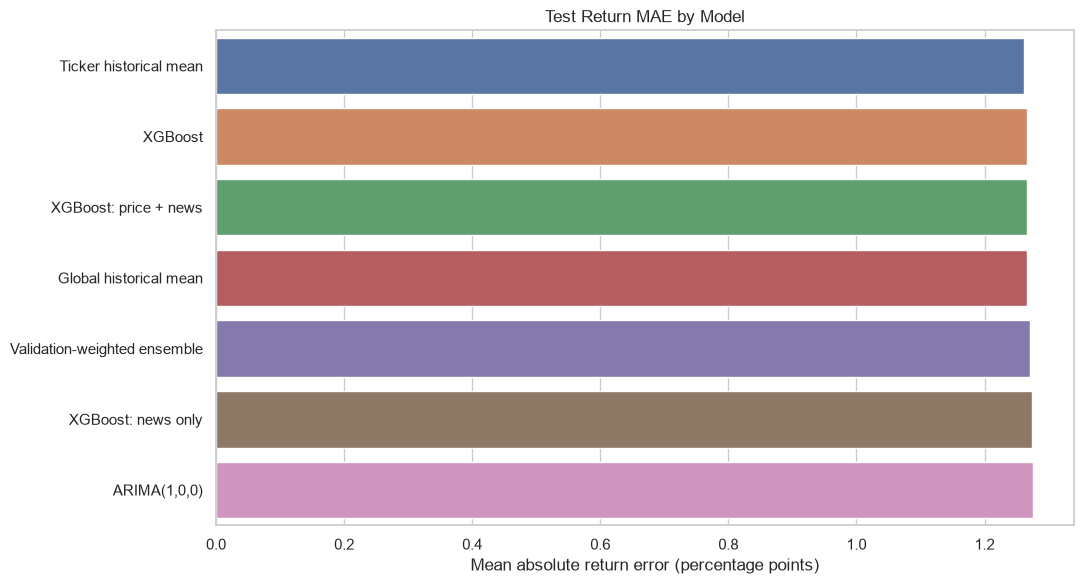

In [13]:
plot_data = (
    test_results
    .dropna(subset=["return_mae"])
    .copy()
)

plot_data["return_mae_pct"] = (
    plot_data["return_mae"] * 100
)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="return_mae_pct",
    y="model",
    hue="model",
    legend=False,
    ax=ax,
)

ax.set(
    title="Test Return MAE by Model",
    xlabel="Mean absolute return error "
    "(percentage points)",
    ylabel="",
)

fig.tight_layout()
plt.show()

### Final test finding

The validation advantage of news-only XGBoost does not persist on the final
test period.

The ticker-specific historical-mean model achieves the lowest test errors.
News-only XGBoost has the same directional accuracy as the positive-return base
rate, so its 58.01% result does not demonstrate genuine discrimination between
positive and negative days.

Per-ticker results

In [15]:
ticker_return_mae = pd.DataFrame(
    {
        "Global historical mean": {
            "AAPL": 0.01005,
            "AMZN": 0.00946,
            "GOOGL": 0.00789,
            "META": 0.00983,
            "MSFT": 0.00722,
            "NVDA": 0.01812,
            "TSLA": 0.02612,
        },
        "Ticker historical mean": {
            "AAPL": 0.01009,
            "AMZN": 0.00944,
            "GOOGL": 0.00797,
            "META": 0.00979,
            "MSFT": 0.00708,
            "NVDA": 0.01783,
            "TSLA": 0.02607,
        },
        "XGBoost: news only": {
            "AAPL": 0.01015,
            "AMZN": 0.00948,
            "GOOGL": 0.00773,
            "META": 0.00998,
            "MSFT": 0.00731,
            "NVDA": 0.01816,
            "TSLA": 0.02642,
        },
    }
)

display(
    ticker_return_mae.style.format("{:.3%}")
)

,Global historical mean,Ticker historical mean,XGBoost: news only
AAPL,1.005%,1.009%,1.015%
AMZN,0.946%,0.944%,0.948%
GOOGL,0.789%,0.797%,0.773%
META,0.983%,0.979%,0.998%
MSFT,0.722%,0.708%,0.731%
NVDA,1.812%,1.783%,1.816%
TSLA,2.612%,2.607%,2.642%


### Where did news help?

News-only XGBoost improves test return MAE only for GOOGL. For the other six
stocks, at least one historical-mean baseline is more accurate.

The largest errors occur for TSLA and NVDA, consistent with their substantially
higher return volatility.

Feature Importance

In [16]:
importance_summary = pd.DataFrame(
    {
        "feature": [
            "median_sentiment",
            "mean_sentiment",
            "ticker_NVDA",
            "neutral_share",
            "sentiment_std",
            "ticker_TSLA",
            "minimum_sentiment",
            "positive_share",
            "article_count",
            "unique_headline_count",
            "has_news",
        ],
        "importance_mean": [
            0.000061,
            0.000055,
            0.000032,
            0.000023,
            0.000014,
            0.000012,
            0.000007,
            0.000004,
            0.000002,
            0.000002,
            0.000000,
        ],
        "importance_std": [
            0.000019,
            0.000041,
            0.000043,
            0.000039,
            0.000012,
            0.000038,
            0.000034,
            0.000015,
            0.000020,
            0.000003,
            0.000000,
        ],
    }
)

display(
    importance_summary.style.format(
        {
            "importance_mean": "{:.6f}",
            "importance_std": "{:.6f}",
        }
    )
)

,feature,importance_mean,importance_std
0,median_sentiment,0.000061,0.000019
1,mean_sentiment,0.000055,0.000041
2,ticker_NVDA,0.000032,0.000043
3,neutral_share,0.000023,0.000039
4,sentiment_std,0.000014,0.000012
5,ticker_TSLA,0.000012,0.000038
6,minimum_sentiment,0.000007,0.000034
7,positive_share,0.000004,0.000015
8,article_count,0.000002,0.000020
9,unique_headline_count,0.000002,0.000003


### Which news variables mattered?

Median and mean sentiment are the most useful news features. Article count,
unique headline count, and simply having news contribute approximately zero.

News tone is therefore more informative than news volume. However, the absolute
importance values remain small, and several estimates have substantial
uncertainty. These results are descriptive rather than causal.

News Availability Results

In [17]:
news_availability = pd.DataFrame(
    {
        "News availability": [
            "Days without news",
            "Days without news",
            "Days with news",
            "Days with news",
        ],
        "Observations": [39, 39, 192, 192],
        "Model": [
            "Global historical mean",
            "XGBoost: news only",
            "Global historical mean",
            "XGBoost: news only",
        ],
        "Return MAE": [
            0.00940,
            0.00932,
            0.01334,
            0.01344,
        ],
        "Return RMSE": [
            0.01371,
            0.01364,
            0.02350,
            0.02365,
        ],
        "Directional accuracy": [
            0.7179,
            0.7179,
            0.5521,
            0.5521,
        ],
    }
)

display(
    news_availability.style.format(
        {
            "Return MAE": "{:.3%}",
            "Return RMSE": "{:.3%}",
            "Directional accuracy": "{:.2%}",
        }
    )
)

,News availability,Observations,Model,Return MAE,Return RMSE,Directional accuracy
0,Days without news,39,Global historical mean,0.940%,1.371%,71.79%
1,Days without news,39,XGBoost: news only,0.932%,1.364%,71.79%
2,Days with news,192,Global historical mean,1.334%,2.350%,55.21%
3,Days with news,192,XGBoost: news only,1.344%,2.365%,55.21%


### News versus no-news days

Days with news are substantially harder to predict. Under historical drift,
test return MAE increases from 0.940% on no-news days to 1.334% on news days.

This is an association rather than evidence that news causes volatility. News
providers publish more coverage around material announcements, controversy,
earnings, and unusual market activity.

News-only XGBoost does not improve predictions on active-news days. Its return
MAE is 1.344%, compared with 1.334% for historical drift.

## 6. Final recommendation

News-only XGBoost was the strongest validation candidate, but its advantage was
regime-dependent and did not survive the final test period.

The ticker-specific historical-mean forecast is the preferred final benchmark:

- **Test price MAE:** $3.184
- **Test price RMSE:** $5.447
- **Test return MAE:** 1.261%
- **Test return RMSE:** 2.214%
- **Directional accuracy:** 58.01%

Median and mean sentiment contain measurable validation signal, and news
improves GOOGL forecasts during the test period. However, this one-year sample
does not demonstrate that the signal is stable enough to outperform historical
drift consistently.

For a production decision, historical drift should remain the champion model.
News-only XGBoost should be treated as a challenger requiring evaluation over
longer histories and multiple market regimes.



## Limitations

1. Only 241 trading sessions are available per ticker.
2. The universe contains seven correlated, technology-oriented companies.
3. News timestamp timezones are undocumented.
4. News coverage is uneven and subject to provider-selection effects.
5. Recurring and syndicated content may overweight some events.
6. FinBERT was not calibrated specifically to these sources or forecast horizon.
7. Market indices, VIX, rates, sector returns, and earnings calendars are absent.
8. The final test period represents only one market regime.
9. Forecasting metrics do not account for transaction costs and do not establish.
   a profitable trading strategy.
10. Only three days to present a solution.

Future work

The highest-value next steps involve broader data and stronger temporal
validation rather than model complexity alone:

- Extend the history across multiple market regimes.
- Add QQQ, S&P 500, VIX, rates, sector ETFs, and earnings events.
- Engineer sentiment surprise and multi-session news carryover.
- Add leave-one-out market returns and rolling abnormal returns.
- Evaluate five-day returns as a secondary news-impact horizon.
- Apply expanding-window cross-validation to a longer dataset.
- Generate conformal prediction intervals.
- Explore temporally constrained semantic retrieval of analogous historical news
  and their already-observed market reactions.

## Reproducibility map

- `01_data_quality_eda.ipynb` contains the full data audit and exploratory
  analysis.
- `02_modeling_validation.ipynb` contains feature engineering, FinBERT scoring,
  chronological validation, model training, and error analysis.
- `03_executive_report.ipynb` provides the concise reviewer-facing narrative
  using saved artifacts.